In [67]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import pandas as pd

In [60]:
df = pd.read_csv("DBSCAN_data.csv")
df.head()

,Year_Birth,Education,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,...,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Status_Partnered,Status_Post-partnered,Status_Single
0,-0.985345,0.25,0.235327,-0.825218,-0.929894,-1.531185,0.307039,0.983781,1.551577,1.679702,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
1,-1.235733,0.25,-0.235826,1.032559,0.906934,1.190545,-0.383664,-0.870479,-0.636301,-0.713225,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,-0.317643,0.25,0.773633,-0.825218,-0.929894,0.205773,-0.798086,0.362723,0.570804,-0.177032,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,1.268149,0.25,-1.022732,1.032559,-0.929894,1.061881,-0.798086,-0.870479,-0.560857,-0.651187,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,1.017761,1.00,0.241519,1.032559,-0.929894,0.953012,1.550305,-0.389085,0.419916,-0.216914,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [61]:
dbscan = DBSCAN(eps=2.5, min_samples=5)
clusters = dbscan.fit_predict(df)

df['DBSCAN_Cluster'] = clusters

In [62]:
print(df['DBSCAN_Cluster'].value_counts())

DBSCAN_Cluster
 0    1476
-1     745
 1      14
 2       5
Name: count, dtype: int64


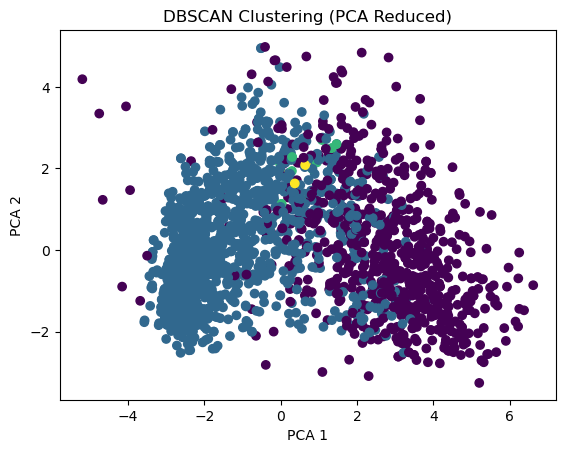

In [63]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(df.drop('DBSCAN_Cluster', axis=1))

plt.scatter(X_pca[:,0], X_pca[:,1], c=df['DBSCAN_Cluster'])
plt.title("DBSCAN Clustering (PCA Reduced)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

In [64]:
DBSCAN(eps=1.2, min_samples=5)
DBSCAN(eps=1.8, min_samples=5)
DBSCAN(eps=2.0, min_samples=4)

,eps,2.0
,min_samples,4
,metric,'euclidean'
,metric_params,None
,algorithm,'auto'
,leaf_size,30
,p,None
,n_jobs,None


In [65]:
df.groupby('DBSCAN_Cluster').mean()

,Year_Birth,Education,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,...,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Status_Partnered,Status_Post-partnered,Status_Single
DBSCAN_Cluster,,,,,,,,,,,,,,,,,,,,,
-1,-0.102432,0.509396,0.781607,-0.580839,-0.269129,-0.188481,-0.008598,0.877610,0.816917,0.907298,...,0.104698,0.139597,0.209396,0.179866,0.032215,0.006711,0.277852,0.587919,0.170470,0.241611
0,0.054434,0.512195,-0.398405,0.303797,0.124166,0.110486,0.001019,-0.461246,-0.406868,-0.454700,...,0.056233,0.036585,0.004743,0.006775,0.002033,0.010840,0.085366,0.672764,0.122629,0.204607
1,-0.222257,0.678571,0.352447,-0.825218,0.906934,-1.129288,0.270037,1.936807,-0.436913,-0.172284,...,0.071429,0.642857,0.000000,0.000000,0.214286,0.000000,0.000000,0.571429,0.071429,0.357143
2,-0.184102,0.350000,0.162668,-0.825218,0.906934,-1.369861,0.224155,-0.027147,-0.389851,-0.477478,...,0.200000,0.000000,0.000000,0.000000,0.000000,0.000000,0.200000,1.000000,0.000000,0.000000


In [68]:
score = silhouette_score(df.drop(['DBSCAN_Cluster'], axis=1), df['DBSCAN_Cluster'])
print("Silhouette Score:", score)

Silhouette Score: 0.07871052612410673
